In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

# Standard library imports
import argparse
import importlib.util
import inspect
import json
import math
import os
import pickle
import random
import shutil
import socket
import subprocess
import sys
import tempfile
import warnings
from functools import reduce

# Third-party imports
import librosa
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from matplotlib import cm
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import umap
from pathlib import Path
import cv2

from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget, BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Local imports
import commons
import lightning_wrapper
import models
import utils
import train
from cough_datasets import (
    CoughDatasets,
    CoughDatasetsCollate,
    CoughDatasetsProcessorCollate,
    CoughDetectionRatioBatchSampler,
    CoughDiseaseBinaryBatchSampler,
    PatientBatchSampler
)

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

def find_bilstmatt_logmel_logs(root="."):
    root = Path(root)
    log_folders = set()

    for p in root.rglob("bilstmatt_logmel"):
        if p.is_dir():
            parent = p.parent
            if parent.name == "logs" or parent.name.startswith("logs_"):
                log_folders.add(parent)

    return sorted(str(p) for p in log_folders)

class CAMWrapper(torch.nn.Module):
    def __init__(self, lightning_model):
        super().__init__()
        self.lightning_model = lightning_model

    def forward(self, x):
        out = self.lightning_model(x)
        return out["disease_logits"]

class SplitStreamCAMWrapper(nn.Module):
    def __init__(self, model, stream_idx: int):
        super().__init__()
        self.model = model
        self.stream_idx = stream_idx  # 0=raw, 1=delta, 2=deltadelta

    def forward(self, s):
        z = self.model.forward_encoder(s.unsqueeze(1))
        logits = self.model.classifier(z)
        return logits

def minmax_norm(x, eps=1e-8):
    return (x - x.min()) / (x.max() - x.min() + eps)

def cosine_sim(x, y, axis):
    num = np.sum(x * y, axis=axis)
    den = np.linalg.norm(x, axis=axis) * np.linalg.norm(y, axis=axis)
    return num / (den + 1e-8)

def unified_confidence(p, tau=0.4484136):
    """
    Returns signed confidence in range [-100, +100].
    Positive = TB
    Negative = Non-TB
    0 = exactly at decision threshold
    """
    if p >= tau:
        # TB side
        return 100.0 * (p - tau) / (1.0 - tau)
    else:
        # Non-TB side
        return -100.0 * (tau - p) / tau

def reduce_embeddings(embeddings, method="umap", random_state=42):
    if method == "umap":
        reducer = umap.UMAP(
            n_neighbors=15,
            min_dist=0.1,
            n_components=2,
            random_state=random_state
        )
    elif method == "tsne":
        reducer = TSNE(
            n_components=2,
            perplexity=30,
            learning_rate="auto",
            init="pca",
            random_state=random_state
        )
    else:
        raise ValueError("method must be 'umap' or 'tsne'")
    
    return reducer.fit_transform(embeddings)


def scatter_plot(Z, color, title, cmap="viridis", cbar_label=None):
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(Z[:, 0], Z[:, 1], c=color, cmap=cmap, s=12, alpha=0.8)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    if cbar_label is not None:
        cbar = plt.colorbar(sc)
        cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_2586378/813940832.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [2]:
experiments = ["logs_nfft2048/bilstmatt_logmel", "logs_nfft2048/bilstmatt_gtgram", "logs_nfft2048/bilstmatt_mfcc",
               "logs_nfft2048/resnet34re_logmel", "logs_nfft2048/resnet34re_gtgram", "logs_nfft2048/resnet34re_mfcc",
               "logs_ssl/qwenasp_peft", "logs_ssl/wavlmasp_peft"]
#experiments = ["logs/bilstmmultimask2_logmel"] #["logs/resnet34multimask_logmel"]       
experiments = ["logs_featcompare/bilstm_logmel"]
use_cpu = True

dfs = []
for now_experiment in experiments:
    experiment_metadata = now_experiment.split("/")
    parser = train.parse_args()
    args = parser.parse_args(["--model_name", experiment_metadata[1]])
    #log_folder = find_bilstmatt_logmel_logs(".")[0]
    model_dir = os.path.join(experiment_metadata[0], args.model_name)

    config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
    hps = train.load_config(config_path, model_dir, args)

    # =============================================================
    # SECTION: Loading Data
    # =============================================================
    df_train, df_test = train.load_data(hps)
    collate_fn = train.get_collate_fn(hps)
    target_labels = df_train[hps.data.target_column]

    logger = utils.get_logger(hps.model_dir, filename="dummy.log")
    logger.info(hps)

    pool_net, pool_model = train.setup_model(hps, is_init=args.init)
    runner_lightning = lightning_wrapper.CoughClassificationRunner.load_from_checkpoint(
        os.path.join(hps.model_dir, "best_model.ckpt"),
        model=pool_model,
        hps=hps, custom_logger=logger
    )
    runner_lightning.eval()
    trainer = L.Trainer(accelerator="gpu" if use_cpu == False else "cpu", devices="auto")

    # with open(os.path.join(model_dir, "probs_threshold.pkl"), "rb") as f:
    #     runner_lightning.probs_threshold = pickle.load(f)['probs_threshold']

    info_fold_data = train.load_fold_info(hps.model_dir)
    best_fold_idx = info_fold_data.get("best_fold_idx", 0)
    runner_lightning.probs_threshold = info_fold_data['best_threshold']

    train_dataset = CoughDatasets(
        df_train.values, 
        hps.data,
        wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle", 
        train=False
    )
    test_dataset = CoughDatasets(
        df_test.values, 
        hps.data,
        wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle", 
        train=False
    )
    
    # Create sampler
    #sampler = train.create_sampler(train_fold, hps)
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset, 
        num_workers=28, 
        #sampler=sampler, 
        batch_size=hps.train.batch_size,
        pin_memory=True, 
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset, 
        num_workers=28, 
        shuffle=False, 
        batch_size=hps.train.batch_size,
        pin_memory=True, 
        collate_fn=collate_fn
    )

    test_wavnames = []
    test_probs = []
    test_preds = []
    test_labels = []
    #test_embeddings = []
    with torch.no_grad():
        for idx, batch in tqdm(enumerate(train_loader), total=len(train_loader)):
            wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _, _] = batch
            audio = audio.cuda()
            attention_masks = attention_masks.cuda()
            out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
            logits = out_model['disease_logits']

            probs = torch.sigmoid(logits).squeeze(-1)  # [B]
            preds = (probs >= runner_lightning.probs_threshold).long().cpu().detach().numpy()
            labels = torch.argmax(dse_ids, dim=1).cpu().detach().numpy()

            test_wavnames.extend(wavnames)
            test_labels.extend(labels)
            test_preds.extend(preds)
            test_probs.extend(probs.cpu().detach().numpy())
            #test_embeddings.extend(out_model['embeddings'].cpu().detach().numpy())

        for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader)):
            wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _, _] = batch
            audio = audio.cuda()
            attention_masks = attention_masks.cuda()
            out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
            logits = out_model['disease_logits']

            probs = torch.sigmoid(logits).squeeze(-1)  # [B]
            preds = (probs >= runner_lightning.probs_threshold).long().cpu().detach().numpy()
            labels = torch.argmax(dse_ids, dim=1).cpu().detach().numpy()

            test_wavnames.extend(wavnames)
            test_labels.extend(labels)
            test_preds.extend(preds)
            test_probs.extend(probs.cpu().detach().numpy())
            #test_embeddings.extend(out_model['embeddings'].cpu().detach().numpy())

    del audio, attention_masks
    test_wavnames = np.array(test_wavnames)
    test_labels = np.array(test_labels)
    test_preds = np.array(test_preds)
    test_probs = np.array(test_probs)
    #test_embeddings = np.array(test_embeddings)

    df_now = pd.DataFrame({
        "path_file": test_wavnames,
        experiment_metadata[1]: test_preds,
        experiment_metadata[1] + "_probs": test_probs
    })
    dfs.append(df_now)

final_df = reduce(
    lambda left, right: pd.merge(left, right, on="path_file", how="inner"),
    dfs
)

df_train['split'] = "train"
df_test['split'] = "test"

df_all = pd.concat([df_train, df_test])
df_all.reset_index(inplace=True, drop=True)

df_result = df_all.merge(
    final_df,
    on="path_file",
    how="inner",
    validate="one_to_one"
)

INFO:bilstm_logmel:{'train': {'use_cuda': True, 'log_interval': 20, 'seed': 1234, 'epochs': 10000, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'betas': [0.8, 0.99], 'eps': 1e-09, 'lr_decay': 0.999875, 'batch_size': 128, 'loss_function': 'BCE', 'use_Kfold': True, 'mae_training': False, 'ssccl_training': False}, 'data': {'max_wav_value': False, 'mean_std_norm': True, 'per_band_norm': False, 'sampling_rate': 16000, 'filter_length': 2048, 'hop_length': 256, 'win_length': 512, 'n_mel_channels': 80, 'mel_fmin': 50.0, 'mel_fmax': 8000.0, 'saming_length': True, 'desired_length': 0.55, 'fade_samples_ratio': 16, 'pad_types': 'zero', 'rezize_size': [64, 256], 'tabular_feature': True, 'acoustic_feature': True, 'feature_type': 'logmel', 'delta_feature': False, 'deltadelta_feature': False, 'multimask_augment': False, 'multimask_prob': 0.4, 'tau': 0.1, 'nu': 0.1, 'num_masks': 4, 'augment_data': True, 'augment_prob': 0.5, 'augment_rawboost': True, 'add_noise': False, 'cough_detection': False, 'mi

INFO:bilstm_logmel:Trainable params: 13459073 | Total params: 13459073 | Trainable%: 100.00% | Size: 13.46M


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
100%|██████████| 15/15 [00:03<00:00,  4.60it/s]


# Calibration Things

In [5]:
def get_diagram_data( y, p, n_bins ):
	n_bins = float( n_bins )	# a float to take care of division

	# we'll append because some bins might be empty
	mean_predicted_values = np.empty(( 0, ))
	true_fractions = np.zeros(( 0, ))

	for b in range( 1, int( n_bins ) + 1 ):
		i = np.logical_and( p <= b / n_bins, p > ( b - 1 ) / n_bins )	# indexes for p in the current bin
		
		# skip bin if empty
		if np.sum( i ) == 0:
			continue

		mean_predicted_value = np.mean( p[i] )
		# print "***", np.sum( y[i] ), np.sum( i )
		true_fraction = np.sum( y[i] ) / np.sum( i )					# y are 0/1; i are logical and evaluate to 0/1

		mean_predicted_values = np.hstack(( mean_predicted_values, mean_predicted_value ))
		true_fractions = np.hstack(( true_fractions, true_fraction ))
		
	return ( mean_predicted_values, true_fractions )

In [ ]:
test_wavnames = []
test_probs = []
test_preds = []
test_labels = []
#test_embeddings = []
with torch.no_grad():
    for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader)):
        wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _, _] = batch
        audio = audio.cuda()
        attention_masks = attention_masks.cuda()
        out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
        logits = out_model['disease_logits']

        probs = # torch.sigmoid(logits).squeeze(-1)  # [B]
        preds = (probs >= runner_lightning.probs_threshold).long().cpu().detach().numpy()
        labels = torch.argmax(dse_ids, dim=1).cpu().detach().numpy()

        test_wavnames.extend(wavnames)
        test_labels.extend(labels)
        test_preds.extend(preds)
        test_probs.extend(probs.cpu().detach().numpy())

test_wavnames = np.array(test_wavnames)
test_labels = np.array(test_labels)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

100%|██████████| 15/15 [00:03<00:00,  4.06it/s]


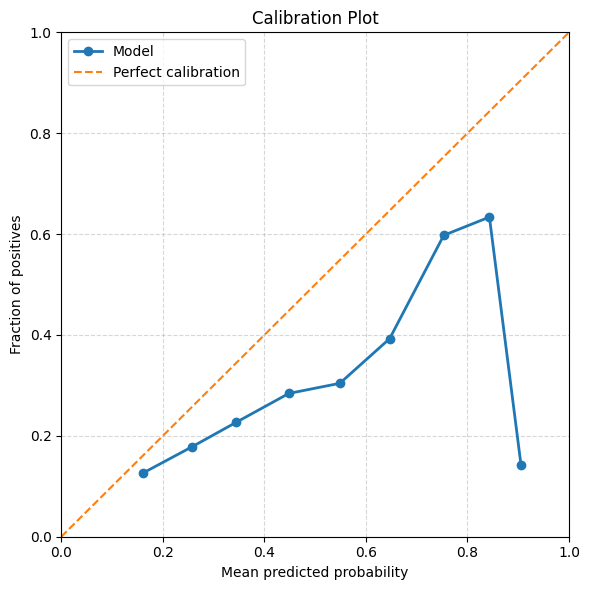

In [12]:
mean_predicted_values, true_fractions = get_diagram_data(test_labels, test_probs, 10)

plt.figure(figsize=(6, 6))

# reliability curve
plt.plot(mean_predicted_values, true_fractions, marker="o", linewidth=2, label="Model")

# perfect calibration reference
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Perfect calibration")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Small Check

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score
)

def compute_metrics(y_true, y_pred, y_score=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    metrics = {
        "Sensitivity": tp / (tp + fn) if (tp + fn) else 0.0,
        "Specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "Accuracy": accuracy_score(y_true, y_pred),
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred),
    }

    if y_score is not None and len(set(y_true)) > 1:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_score)
    else:
        metrics["ROC-AUC"] = float("nan")

    return metrics

def evaluate_file_level(df, selected_model):
    y_true  = df["disease_status"].values
    y_pred  = df[selected_model].values
    y_score = df[selected_model].values  # binary but valid for AUC

    return compute_metrics(y_true, y_pred, y_score)


def evaluate_participant_voting(df, selected_model):
    vote_df = (
        df.groupby("participant")
          .agg(
              disease_status=("disease_status", "first"),
              mean_score=(selected_model, "mean")
          )
    )

    y_true  = vote_df["disease_status"].values
    y_pred  = (vote_df["mean_score"] >= 0.5).astype(int)
    y_score = vote_df["mean_score"].values

    return compute_metrics(y_true, y_pred, y_score)

def compare_file_vs_participant(df, selected_model):
    summary = pd.DataFrame.from_dict(
        {
            "File-level": evaluate_file_level(df, selected_model),
            "Participant-voting": evaluate_participant_voting(df, selected_model)
        },
        orient="index"
    )
    return summary

selected_model = experiment_metadata[1]
selected_df = df_result[df_result['split'] == "test"][['path_file', 'participant', 'disease_status', selected_model]]
summary_df = compare_file_vs_participant(selected_df, selected_model)
print(summary_df)


In [ ]:
splitter, num_folds = train.create_data_split(df_train, target_labels, use_kfold=hps.train.use_Kfold)

for fold, (train_idx, val_idx) in enumerate(splitter):
    logger.info(f"\n{'='*20} Fold {fold+1}/{num_folds} {'='*20}")

    train_fold = df_train.iloc[train_idx].reset_index(drop=True)
    val_fold = df_train.iloc[val_idx].reset_index(drop=True)

In [ ]:
train_participants = set(train_fold['participant'].unique())
test_participants = set(val_fold['participant'].unique())

overlap_participants = train_participants.intersection(test_participants)

n_overlap = len(overlap_participants)
n_test_total = len(test_participants)

100 * n_overlap / n_test_total

In [ ]:
train_participants = set(df_train['participant'].unique())
test_participants = set(df_test['participant'].unique())

overlap_participants = train_participants.intersection(test_participants)

n_overlap = len(overlap_participants)
n_test_total = len(test_participants)

100 * n_overlap / n_test_total

# Check Error Overlap

In [ ]:
from IPython.display import Audio, display

y_col = "disease_status"
participant_col = "participant"
split_col = "split"

symptom_cols = [
    "weight_loss", "hemoptysis", "night_sweats", "smoker"
]

meta_cols = ["gender"] + symptom_cols

model_cols = [
    "bilstmatt_logmel",
    "bilstmatt_gtgram",
    "bilstmatt_mfcc",
    "resnet34re_logmel",
    "resnet34re_gtgram",
    "resnet34re_mfcc",
    "qwenasp_peft",
    "wavlmasp_peft"
]


def compute_error_agreement(df):
    err = df[model_cols].ne(df[y_col], axis=0)
    df = df.copy()
    df["num_models_wrong"] = err.sum(axis=1)
    df["error_agreement_ratio"] = df["num_models_wrong"] / len(model_cols)
    return df

def participant_type(row):
    if row["mean_error_agreement"] > 0.7:
        return "systematically_ambiguous"
    elif row["max_error_agreement"] > 0.7:
        return "locally_ambiguous"
    else:
        return "consistently_easy"

In [ ]:
df_all = []
for split, df_s in df_result.groupby(split_col):
    df_s = compute_error_agreement(df_s)
    df_s["split_name"] = split
    df_all.append(df_s)

df_err = pd.concat(df_all, ignore_index=True)

In [ ]:
participant_summary = (
    df_err
    .groupby([split_col, participant_col])
    .agg(
        n_files=("path_file", "count"),
        mean_error_agreement=("error_agreement_ratio", "mean"),
        max_error_agreement=("error_agreement_ratio", "max")
    )
    .reset_index()
)

participant_summary["participant_type"] = participant_summary.apply(participant_type, axis=1)

In [ ]:
participant_summary['participant_type'].value_counts()

In [ ]:
# Exclude Patient That Hard
ambiguous_participants = (participant_summary.loc[participant_summary['participant_type'] == "systematically_ambiguous", 'participant'])
df_err_filtered = df_err[~df_err['participant'].isin(ambiguous_participants)]

In [ ]:
df_err_files = df_err_filtered[df_err_filtered['error_agreement_ratio'] >= 0.7]
df_err_files['disease_status'].value_counts()

In [ ]:
audio_np, sample_rate = librosa.load(df_err_files.sample(n=1)['path_file'].values[0], sr=16000)

display(Audio(audio_np, rate=sample_rate))
plt.plot(audio_np)

In [ ]:
file_vs_participant = (
    df_err
    .groupby([split_col, participant_col])
    .agg(
        files_high_agreement=("error_agreement_ratio", lambda x: (x > 0.6).sum()),
        total_files=("path_file", "count")
    )
)

file_vs_participant["fraction_files_ambiguous"] = (
    file_vs_participant["files_high_agreement"] /
    file_vs_participant["total_files"]
)

file_vs_participant.reset_index(inplace=True)

In [ ]:
file_vs_participant['fraction_files_ambiguous'].describe()

In [ ]:
participant_meta = (
    df_err
    .groupby([split_col, participant_col])
    .first()[meta_cols]
    .reset_index()
)

participant_analysis = participant_summary.merge(
    participant_meta,
    on=[split_col, participant_col],
    how="left"
)

gender_stats = (
    participant_analysis
    .groupby([split_col, "gender"])["mean_error_agreement"]
    .mean()
    .reset_index()
)

print(gender_stats)

for col in symptom_cols:
    stats = (
        participant_analysis
        .groupby([split_col, col])["mean_error_agreement"]
        .mean()
        .reset_index()
    )
    print(f"\nSymptom: {col}")
    print(stats)


In [ ]:
HIGH_AGREE = 0.6    # ≥60% of models wrong → systematic ambiguity
LOW_AGREE  = 0.0    # all models correct

summary_rows = []

for split, df_s in df_err.groupby(split_col):

    n_files = len(df_s)
    n_participants = df_s[participant_col].nunique()

    # File-level ambiguity
    frac_ambiguous_files = (df_s["error_agreement_ratio"] >= HIGH_AGREE).mean()
    frac_easy_files = (df_s["error_agreement_ratio"] == LOW_AGREE).mean()

    # Participant-level aggregation
    part = (
        df_s
        .groupby(participant_col)
        .agg(
            mean_err=("error_agreement_ratio", "mean"),
            frac_err=("error_agreement_ratio", lambda x: (x >= HIGH_AGREE).mean())
        )
    )

    # Whole particippant is likelywrong
    frac_systematic_participants = (part["mean_err"] >= HIGH_AGREE).mean()
    # Some of Files was Ambigu
    frac_participant_level = (part["frac_err"] >= 0.5).mean()

    # Gender correlation
    gender_gap = (
        df_s
        .groupby("gender")["error_agreement_ratio"]
        .mean()
    )
    gender_delta = (
        gender_gap.max() - gender_gap.min()
        if len(gender_gap) > 1 else np.nan
    )

    # Symptom correlation (mean absolute deltas)
    symptom_deltas = []
    for col in symptom_cols:
        g = df_s.groupby(col)["error_agreement_ratio"].mean()
        if len(g) > 1:
            symptom_deltas.append(g.max() - g.min())

    mean_symptom_delta = np.mean(symptom_deltas) if symptom_deltas else np.nan

    summary_rows.append({
        "split": split,
        "n_files": n_files,
        "n_participants": n_participants,

        # Core evidence
        "ambiguous_files_%": frac_ambiguous_files * 100,
        "easy_files_%": frac_easy_files * 100,

        "systematic_participants_%": frac_systematic_participants * 100,
        "participant_level_ambiguity_%": frac_participant_level * 100,

        # Metadata alignment
        "gender_effect_size": gender_delta,
        "symptom_effect_size": mean_symptom_delta
    })

summary_table = pd.DataFrame(summary_rows)
summary_table


In [ ]:
df_err

In [ ]:
df_e_t = df_err[df_err['split'] == "train"]
df_e_t[df_e_t["error_agreement_ratio"] >= 0.6]

# UMAP & TSNE

In [ ]:
for method in ["umap", "tsne"]:
    Z = reduce_embeddings(test_embeddings, method=method)
    scatter_plot(
        Z,
        color=test_labels,
        title=f"{method.upper()} – Colored by Ground Truth Labels",
        cmap="coolwarm",
        cbar_label="Label (0=Neg, 1=Pos)"
    )


In [ ]:
# Encode confusion categories
# 0: TN, 1: FP, 2: FN, 3: TP
conf_map = {
    (0, 0): 0,
    (0, 1): 1,
    (1, 0): 2,
    (1, 1): 3,
}

conf_labels = np.array([
    conf_map[(y, p)] for y, p in zip(test_labels, test_preds)
])

conf_names = ["TN", "FP", "FN", "TP"]
conf_cmap = plt.get_cmap("tab10")

for method in ["umap", "tsne"]:
    Z = reduce_embeddings(test_embeddings, method=method)
    scatter_plot(
        Z,
        color=conf_labels,
        title=f"{method.upper()} – Confusion Matrix View",
        cmap=conf_cmap,
        cbar_label="0:TN  1:FP  2:FN  3:TP"
    )


In [ ]:
threshold = runner_lightning.probs_threshold
test_probs = test_probs.squeeze()

# Signed distance to decision boundary
prob_margin = test_probs - threshold
for method in ["umap", "tsne"]:
    Z = reduce_embeddings(test_embeddings, method=method)
    scatter_plot(
        Z,
        color=prob_margin,
        title=f"{method.upper()} – Probability Margin (Threshold = {threshold:.2f})",
        cmap="coolwarm",
        cbar_label="p − threshold"
    )


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(test_embeddings, test_labels)
knn_preds = knn.predict(test_embeddings)

print("kNN BalAcc:", balanced_accuracy_score(test_labels, knn_preds))

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 15
nbrs = NearestNeighbors(n_neighbors=k).fit(test_embeddings)
_, idx = nbrs.kneighbors(test_embeddings)

def label_entropy(labels):
    p = np.bincount(labels, minlength=2) / len(labels)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

local_entropy = np.array([
    label_entropy(test_labels[i_neighbors])
    for i_neighbors in idx
])

scatter_plot(
    Z,
    color=local_entropy,
    title="UMAP – Local Label Entropy",
    cmap="inferno",
    cbar_label="Label entropy"
)


In [ ]:
from scipy.stats import spearmanr

rho, p = spearmanr(test_probs, np.linalg.norm(test_embeddings, axis=1))
print(rho, p)

In [ ]:
# error indices for multiple models
err_sets = [set(err_idx_model_i), set(err_idx_model_j)]
jaccard = len(err_sets[0] & err_sets[1]) / len(err_sets[0] | err_sets[1])
print("Error overlap:", jaccard)


# XAI

In [25]:
seleted_column = experiment_metadata[1]
df_result_test = df_result[df_result['split'] == 'test']
df_result_test["CM"] = np.select(
    [
        (df_result_test["disease_status"] == 1) & (df_result_test[seleted_column] == 1),
        (df_result_test["disease_status"] == 0) & (df_result_test[seleted_column] == 0),
        (df_result_test["disease_status"] == 0) & (df_result_test[seleted_column] == 1),
        (df_result_test["disease_status"] == 1) & (df_result_test[seleted_column] == 0),
    ],
    ["TP", "TN", "FP", "FN"],
    default="UNK"
)

/tmp/ipykernel_2838162/2560308193.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_test["CM"] = np.select(


## Attention

In [ ]:
cm_modes = "TP"
df_subset = df_result_test[df_result_test['CM'] == cm_modes]
df_subset = df_subset[hps.data.column_order]

dataset = CoughDatasets(
    df_subset.values, 
    hps.data,
    wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle", 
    train=False
)
loader = DataLoader(
    dataset, 
    num_workers=28, 
    shuffle=True,
    batch_size=hps.train.batch_size, 
    pin_memory=True, 
    collate_fn=collate_fn
)

results = trainer.test(runner_lightning, dataloaders=loader)[0]


with torch.no_grad():
    for idx, batch in tqdm(enumerate(loader), total=len(loader)):
        wavnames, audios, _, attention_masks, dse_ids, [patient_ids, _, _] = batch
        out_model = runner_lightning.model.forward(audios, attention_mask=attention_masks)
        logits = out_model['disease_logits']

        probs = torch.sigmoid(logits).squeeze(-1)  # [B]
        #preds = (probs >= 0.5).long()
        dse_ids = torch.argmax(dse_ids, dim=1)
        break

In [ ]:
selected_index = random.randint(0, len(audios) - 1)

audio = minmax_norm(audios[selected_index])
t_att = minmax_norm(out_model['asp_weights'][selected_index].mean(dim=0)).cpu().detach().numpy()
se_att = minmax_norm(out_model['self_attn_weights'][selected_index].mean(dim=0)).cpu().detach().numpy()
time_x = np.arange(audio.shape[-1])

mel_np = np.flipud(audio.numpy())
cmap = cm.get_cmap("viridis")
mel_rgb = cmap(mel_np)[..., :3]

preds_prob = unified_confidence(probs[selected_index], runner_lightning.probs_threshold)
true_label = dse_ids[selected_index]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5, 8), sharex=True)
axes[0].imshow(mel_rgb, aspect='auto', extent=[time_x[0], time_x[-1], 0, mel_rgb.shape[0]])
axes[0].set_title(f"{cm_modes} - Label {true_label} - Pred Prob {preds_prob:.2f}")

axes[1].plot(time_x, t_att)
axes[1].set_title("Attentive Pooling Weight")
axes[1].set_xlabel("Time Frame")

axes[2].plot(time_x, se_att)
axes[2].set_title("Mean Self Attention Weight")
axes[2].set_xlabel("Time Frame")

plt.tight_layout()
plt.show()

In [ ]:
attn = out_model['self_attn_weights'][selected_index].detach().cpu().numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(attn, cmap="viridis", square=True)
plt.xlabel("Key Time Frame")
plt.ylabel("Query Time Frame")
plt.tight_layout()
plt.show()

In [ ]:
T = attn.shape[0]

top_idx = torch.topk(out_model['asp_weights'][selected_index].mean(dim=0), 10).indices
masked = attn[top_idx].mean(0)

plt.figure(figsize=(6, 2))
plt.plot(masked)
plt.title("Decision-Conditioned Attention")
plt.xlabel("Time Frame")
plt.ylabel("Attention")
plt.tight_layout()
plt.show()

## Gradcam

In [26]:
df_subset = df_result_test[df_result_test['CM'] == "TP"]
df_subset = df_subset[hps.data.column_order]
dataset_tp = CoughDatasets(df_subset.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle", train=False)
loader_tp = DataLoader(dataset_tp,  num_workers=28,  shuffle=True, batch_size=hps.train.batch_size,  pin_memory=True,  collate_fn=collate_fn)

df_subset = df_result_test[df_result_test['CM'] == "TN"]
df_subset = df_subset[hps.data.column_order]
dataset_tn = CoughDatasets(df_subset.values, hps.data, wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle", train=False)
loader_tn = DataLoader(dataset_tn,  num_workers=28,  shuffle=True, batch_size=hps.train.batch_size,  pin_memory=True,  collate_fn=collate_fn)

100%|██████████| 8/8 [00:01<00:00,  5.60it/s]


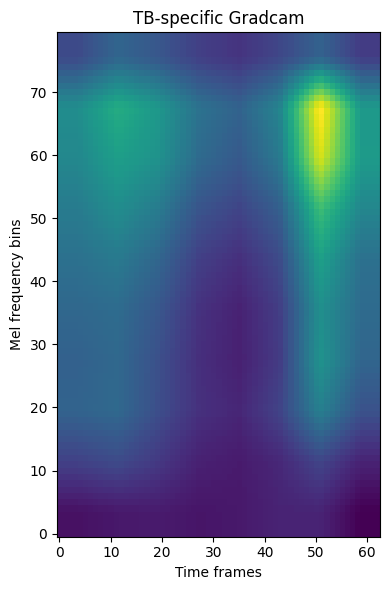

In [29]:
TARGET_LABEL = 1
target_layers = [runner_lightning.model.encoder1.layer4]

all_cams = []
for idx, batch in tqdm(enumerate(loader_tp), total=len(loader_tp)):
    wavnames, audios, _, attention_masks, dse_ids, [patient_ids, _, _, _] = batch
    audios = audios.squeeze(1)
    dse_ids = torch.argmax(dse_ids, dim=1) # [128]
  
    cam_model = CAMWrapper(runner_lightning.model)
    targets = [BinaryClassifierOutputTarget(TARGET_LABEL) for _ in range(audios.size(0))]
    # targets = [BinaryClassifierOutputTarget(1) for _ in range(audios.size(0))]
    with GradCAM(model=cam_model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=audios, targets=targets) # (B, 80, 63) 

    cam_min = grayscale_cam.min(axis=(1,2), keepdims=True)
    cam_max = grayscale_cam.max(axis=(1,2), keepdims=True)
    grayscale_cam = (grayscale_cam - cam_min) / (cam_max - cam_min + 1e-6)
    all_cams.append(grayscale_cam)

for idx, batch in tqdm(enumerate(loader_tn), total=len(loader_tn)):
    wavnames, audios, _, attention_masks, dse_ids, [patient_ids, _, _, _] = batch
    audios = audios.squeeze(1)
    dse_ids = torch.argmax(dse_ids, dim=1) # [128]
  
    cam_model = CAMWrapper(runner_lightning.model)
    targets = [BinaryClassifierOutputTarget(TARGET_LABEL) for _ in range(audios.size(0))]
    with GradCAM(model=cam_model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=audios, targets=targets) # (B, 80, 63) 

    cam_min = grayscale_cam.min(axis=(1,2), keepdims=True)
    cam_max = grayscale_cam.max(axis=(1,2), keepdims=True)
    grayscale_cam = (grayscale_cam - cam_min) / (cam_max - cam_min + 1e-6)
    all_cams.append(grayscale_cam)

all_cams = np.concatenate(all_cams, axis=0)  # (N_TP, 80, 63)
mean_cam   = all_cams.mean(axis=0)        # (80, 63)
median_cam = np.median(all_cams, axis=0)  # more robust to label noise

plt.figure(figsize=(4, 6))
plt.imshow(mean_cam, origin="lower", aspect='auto')
plt.xlabel("Time frames")
plt.ylabel("Mel frequency bins")
plt.title(f"TB-specific Gradcam")
plt.tight_layout()
plt.show()

In [ ]:
for idx, batch in tqdm(enumerate(loader_tp), total=len(loader_tp)):
    wavnames, audios, _, attention_masks, dse_ids, [patient_ids, _, _] = batch
    audios = audios.squeeze(1)
    dse_ids = torch.argmax(dse_ids, dim=1) # [128]
    break

In [ ]:
selected_index = random.randint(0, len(audios) - 1)

audio = minmax_norm(audios[selected_index]).squeeze(0)
mel_np = np.flipud(audio.numpy())
cmap = cm.get_cmap("viridis")
mel_rgb = cmap(mel_np)[..., :3]

#preds_prob = probs[selected_index] #unified_confidence(probs[selected_index], runner_lightning.probs_threshold)
true_label = dse_ids[selected_index]

cam_model = CAMWrapper(runner_lightning.model)
target_layers = [runner_lightning.model.encoder1.layer4]
targets = [BinaryClassifierOutputTarget(int(true_label))]
input_tensor = audios[selected_index].unsqueeze(0)

with GradCAM(model=cam_model, target_layers=target_layers) as cam:
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
  grayscale_cam = np.flipud(grayscale_cam[0, :])
  visualization = show_cam_on_image(mel_rgb, grayscale_cam, use_rgb=True, colormap=cv2.COLORMAP_HOT, image_weight=0.5)
  model_outputs = cam.outputs

visualization = np.flipud(visualization)

plt.figure(figsize=(4, 6))
plt.imshow(visualization, origin="lower", aspect='auto')
plt.xlabel("Time frames")
plt.ylabel("Mel frequency bins")
plt.title(f"Label {true_label}")
plt.tight_layout()
plt.show()

In [ ]:
wavnames[selected_index]

In [ ]:
cam_model_split = SplitStreamCAMWrapper(runner_lightning.model, stream_idx=0)
target_layers = [runner_lightning.model.layer4, runner_lightning.model.layer3]

for i, name in enumerate(["raw", "delta", "deltadelta"]):
    streams = torch.split(input_tensor, 80, dim=1)
    s = streams[i]

    splits_original_image = np.split(image_original, 3, axis=0)
    with GradCAM(model=cam_model_split, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=s, targets=targets)
        grayscale_cam = np.flipud(grayscale_cam[0])
        visualization = show_cam_on_image(splits_original_image[i], grayscale_cam, use_rgb=True, image_weight=0.8)

    images = [splits_original_image[i], grayscale_cam, visualization]
    titles = [f"GT",
                f"Heatmap (Pred",
                "Overlayed Heatmap"]

    plt.figure(figsize=(21, 18))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(images[i])
        plt.axis('off')
        plt.title(titles[i], fontdict={"size": 18})
        plt.tight_layout()
    plt.show()

# Lets Find Out Why it Fail

In [ ]:
# Select Where bilstmatt_logmel always wrong and bilstmatt_mfcc always right
df_filtered = df_result[
    (df_result["split"] == "test") &
    (
        (df_result["bilstmatt_mfcc"] >= 0.5).astype(int)
        == df_result["disease_status"]
    ) &
    (
        (df_result["bilstmatt_logmel"] >= 0.5).astype(int)
        != df_result["disease_status"]
    )
]

In [ ]:
out_models = {}
for now_experiment in experiments:
    parser = train.parse_args()
    args = parser.parse_args(["--model_name", now_experiment])
    model_dir = os.path.join(log_folder, args.model_name)

    config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
    hps = train.load_config(config_path, model_dir, args)
    collate_fn = train.get_collate_fn(hps)

    logger = utils.get_logger(hps.model_dir, filename="dummy.log")
    logger.info(hps)

    pool_net, pool_model = train.setup_model(hps, is_init=args.init)
    runner_lightning = lightning_wrapper.CoughClassificationRunner.load_from_checkpoint(
        os.path.join(hps.model_dir, "best_model.ckpt"),
        model=pool_model,
        hps=hps, custom_logger=logger
    )
    runner_lightning.eval()
    info_fold_data = train.load_fold_info(hps.model_dir)
    best_fold_idx = info_fold_data.get("best_fold_idx", 0)

    test_dataset = CoughDatasets(
        df_filtered.values,
        hps.data,
        wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{best_fold_idx}.pickle",
        train=False
    )

    test_loader = DataLoader(
        test_dataset,
        num_workers=28,
        shuffle=False,
        batch_size=hps.train.batch_size,
        pin_memory=True,
        collate_fn=collate_fn
    )

    with torch.no_grad():
        for idx, batch in tqdm(enumerate(test_loader), total=len(test_loader)):
            wavnames, audio, _, attention_masks, dse_ids, [patient_ids, _, _] = batch
            audio = audio.cuda()
            attention_masks = attention_masks.cuda()
            out_model = runner_lightning.model.forward(audio, attention_mask=attention_masks)
            logits = out_model['disease_logits']

            probs = torch.sigmoid(logits).squeeze(-1)  # [B]
            #preds = (probs >= 0.5).long()
            dse_ids = torch.argmax(dse_ids, dim=1)
            break

        out_models[now_experiment] = {
            'audios': audio.cpu().detach(),
            'dse_ids': dse_ids.cpu().detach(),
            'out_model': out_model,
        }

In [ ]:
selected_index = random.randint(0, len(out_models['bilstmatt_logmel']['audios']) - 1)

selected_experiment = "bilstmatt_logmel"
for selected_experiment in out_models.keys():
    probs = torch.sigmoid(out_models[selected_experiment]['out_model']['disease_logits']).squeeze(-1)
    feature_model1 = minmax_norm(out_models[selected_experiment]['audios'][selected_index])
    t_att = out_models[selected_experiment]['out_model']['asp_weights'][selected_index].mean(dim=0).cpu().detach().numpy()
    se_att = out_models[selected_experiment]['out_model']['self_attn_weights'][selected_index].mean(dim=0).cpu().detach().numpy()
    time_x = np.arange(feature_model1.shape[-1])

    mel_np = np.flipud(feature_model1.numpy())
    cmap = cm.get_cmap("viridis")
    mel_rgb = cmap(mel_np)[..., :3]

    preds_prob = probs[selected_index]
    true_label = out_models[selected_experiment]['dse_ids'][selected_index]

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)
    axes[0].imshow(mel_rgb, aspect='auto', extent=[time_x[0], time_x[-1], 0, mel_rgb.shape[0]])
    axes[0].set_title(f"{selected_experiment} - Label {true_label} - Pred Prob {preds_prob:.2f}")

    axes[1].plot(time_x, t_att)
    axes[1].set_title("Attentive Pooling Weight")
    axes[1].set_xlabel("Time Frame")

    axes[2].plot(time_x, se_att)
    axes[2].set_title("Mean Self Attention Weight")
    axes[2].set_xlabel("Time Frame")

    plt.tight_layout()
    plt.show()

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)
time = np.arange(mel_norm.shape[-1])

axes[0].imshow(mel_rgb, aspect='auto', extent=[time[0], time[-1], 0, mel_rgb.shape[0]])
axes[0].set_title("Feature Raw")

axes[1].plot(time, t_att)
axes[1].set_title("Attention Weight")
axes[1].set_xlabel("Time Frame")

plt.tight_layout()
plt.show()